# TP 6: Neural Networks

## Quick Recap: Sotochastic Gradient Descent (SGD)

Gradient Descent is an iterative optimization algorithm that finds the minimum of a loss function by taking steps in the direction of the steepest descent (the negative gradient). 

The update rule is:

$$\theta = \theta - \eta \nabla L(\theta)$$

where:
- $\theta$ represents the model parameters
- $\eta$ is the **learning rate** (step size)
- $\nabla L(\theta)$ is the gradient of the loss function

**Stochastic Gradient Descent** updates parameters using only a small random subset of data at each iteration, rather than the entire dataset. This makes training:

- Faster (fewer data points to process)
- More memory-efficient

## 📝 Exercise 1: Stochastic Gradient Descent for Linear Regression

In this exercise, we will implement the **Stochastic Gradient Descent (SGD)** algorithm from scratch to solve a Linear Regression problem.

### The Problem Setup:

We want to fit a **linear regression model** to synthetic data: $$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \epsilon$$

where:
- $\beta_0$ is the intercept
- $\beta_1, \beta_2$ are the slope coefficients
- $\epsilon$ is Gaussian noise

We'll generate training data from known parameters, then use SGD to recover them.

In [1]:
## Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random

### Part 1: Synthetic Data Generation

In [2]:
## Set the "True" Parameters
n = 60  # Number of samples
b0 = 5  # True intercept (what we want to recover)
b1 = np.array([2, -3])  # True coefficients (what we want to recover)

## Add realistic noise
mue = 0  # Mean of noise
sigmae = 5  # Standard deviation of noise

## Range of input values
xl, xh = 0, 10  # x ranges from 0 to 10

In [3]:
def genSample(n,b0,b1,sigmae,xLow,xHigh,seedit=199,size=1):
    if type(seedit)==int:
        np.random.seed(seedit)
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed(seedit+k)
            x.append(np.random.uniform(xl,xh,n))
    else:
        np.random.seed()
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed()
            x.append(np.random.uniform(xl,xh,n))
    y = b0+Er
    for k in range(size):
        y +=b1[k]*x[k]
    
    ## Output
    if size==1:
        return (x[0], y, Er)
    else:
        return (x, y, Er)

In [4]:
## Use the provided `genSample()` function to create training data
(x,y,Er) = genSample(n,b0,b1,sigmae,xl,xh,seedit=199,size=2)

In [5]:
## Organize into a DataFrame for easier inspection
data1 = {'x1': x[0], 'x2': x[1], 'error': Er, 'y': y}
df_slr = pd.DataFrame(data=data1)
df_slr

,x1,x2,error,y
0,6.547917,9.476323,5.540357,-4.792776
1,9.820393,2.265474,-1.611389,16.232974
2,3.999047,5.944201,11.443719,6.609209
3,8.441526,4.283087,-9.227246,-0.193454
4,4.638424,7.641407,-7.670402,-16.317776
5,5.448431,0.028606,5.449724,21.260768
6,6.194778,3.574237,6.047357,12.714203
7,3.318368,9.096949,-1.463177,-17.117288
8,9.809954,4.560810,-4.815318,6.122161
9,2.610112,9.818027,1.011883,-18.221974


This gives us:
- `x[0]`: First feature, 60 samples
- `x[1]`: Second feature, 60 samples
- `y`: Target variable for each sample
- `Er`: Noise added to each sample

### Part 2: Implementing SGD

In this section, we will evaluate how the performance of Stochastic Gradient Descent (SGD) changes when we adjust two critical hyperparameters: 

- Mini-batch Size (m)
- Learning Rate ($\eta$)

**The Mini-batch Size (m):** This is the amount of data the model looks at before making an update.

**The Learning Rate ($\eta$):** It determines how much we change our parameters after seeing an error. If it's too large, we might skip over the best solution; if it's too small, the model will take forever to learn.

First, complete the logic inside the code cell below. Look for the `##TODO` markers to implement the gradient calculation and the parameter update step. Once your code is working, you will run the SGD algorithm multiple times to find the converged values for the parameters $(b_0,b_1,b_2)$. You should test every combination of the following settings:

- **Mini-batch Size (m):** m=1, m=10, m=n (where n is the full data size)
- **Learning Rate ($\eta$):** $\eta$=0.04, $\eta$=0.01, $\eta$=0.001

In [6]:
## The Complete SGD Function
def LinReg_SGD(T, m, eta, printit=True):
    """
    Stochastic Gradient Descent for Linear Regression
    
    Parameters:
    -----------
    T : int
        Number of epochs (passes through the data)
    m : int
        Mini-batch size (m=1: online, m=n: batch gradient descent)
    eta : float
        Learning rate (larger = faster but risky, smaller = slow but stable)
    
    Returns:
    --------
    [b0List, b1List, b2List, b0_final, b1_final, b2_final]
        Lists of parameter values at each epoch, plus final values
    """
    
    ## Initialize unknown linear parameters randomly
    b1_init = np.random.uniform()
    b2_init = np.random.uniform()
    b0_init = np.random.uniform()
    
    ## Track parameter values through training
    b0 = b0_init
    b0List = [b0]
    b1 = b1_init
    b1List = [b1_init]
    b2 = b2_init
    b2List = [b2]
    
    ## Main training loop
    for t in range(T):
        ## Select a random mini-batch
        if m < n:
            indx = np.random.choice(np.arange(n), size=m, replace=False)
        else:
            indx = np.arange(n)  # Use all data if you want to use all data per iteration
        
        ## Use x_batch and y_batch to store the batch of data
        y_batch = y[indx]
        x_batch = [[x[0][i], x[1][i]] for i in indx]
        x_batch1 = [x_batch[j][0] for j in range(m)]
        x_batch2 = [x_batch[j][1] for j in range(m)]

        y_pred = b0 + b1 * np.array(x_batch1) + b2 * np.array(x_batch2)
        errors = y_batch - y_pred
        
        grad_b0 = -2 * np.mean(errors)
        grad_b1 = -2 * np.mean(errors * np.array(x_batch1))
        grad_b2 = -2 * np.mean(errors * np.array(x_batch2))
        
        ## TODO #2: Update parameters using SGD rule
        b0 = b0 - eta * grad_b0
        b1 = b1 - eta * grad_b1
        b2 = b2 - eta * grad_b2
        
        ## Record values for analysis
        b0List.append(b0)
        b1List.append(b1)
        b2List.append(b2)
        
        ## Print progress
        if t % 100 == 0 and printit == True:
            print(f'Epoch {t:4d} | b0={b0:7.3f} | b1={b1:7.3f} | b2={b2:7.3f}')
    
    return [b0List, b1List, b2List, b0, b1, b2]

In [7]:
## Set hyperparameters
T = 1000 #number of epochs
m = 10 # Batch-size m is less than or equal to n
eta = 0.01 # Learning rate

In [8]:
## Run SGD to estimate parameters
results = LinReg_SGD(T, m, eta, printit=True)
b0List, b1List, b2List, b0, b1, b2 = results

Epoch    0 | b0=  0.276 | b1=  0.991 | b2= -0.268
Epoch  100 | b0=  1.128 | b1=  1.938 | b2= -2.891
Epoch  200 | b0=  1.817 | b1=  2.427 | b2= -2.509
Epoch  300 | b0=  2.305 | b1=  1.974 | b2= -3.126
Epoch  400 | b0=  2.846 | b1=  2.350 | b2= -2.626
Epoch  500 | b0=  3.199 | b1=  2.162 | b2= -2.753
Epoch  600 | b0=  3.524 | b1=  2.301 | b2= -3.241
Epoch  700 | b0=  3.693 | b1=  1.997 | b2= -3.147
Epoch  800 | b0=  3.971 | b1=  2.021 | b2= -2.995
Epoch  900 | b0=  3.980 | b1=  1.983 | b2= -3.339


In [9]:
## Analyze results
print(f"\nTrue parameters:   b0={5.0:.3f}, b1={2.0:.3f}, b2={-3.0:.3f}")
print(f"Learned parameters: b0={b0:.3f}, b1={b1:.3f}, b2={b2:.3f}")


True parameters:   b0=5.000, b1=2.000, b2=-3.000
Learned parameters: b0=4.165, b1=2.426, b2=-2.739


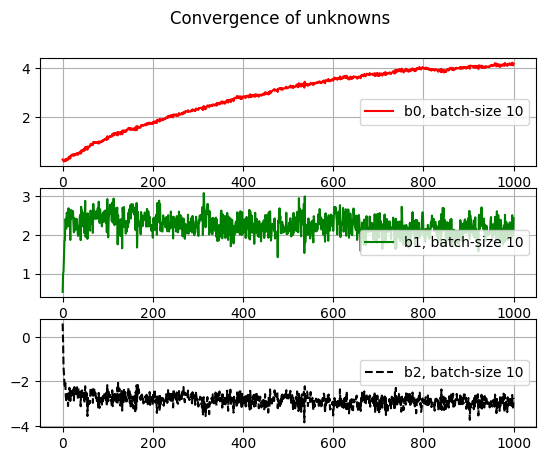

In [10]:
fig, axs = plt.subplots(3)
fig.suptitle('Convergence of unknowns')

## Plot parameter convergence 'b0'
axs[0].plot(b0List,'r',label='b0, batch-size 10')
axs[0].legend(loc=7)
axs[0].grid()

## Plot parameter convergence 'b1'
axs[1].plot(b1List,'g',label='b1, batch-size 10')
axs[1].legend(loc=7)
axs[1].grid()

## Plot parameter convergence 'b2'
axs[2].plot(b2List,'--k',label='b2, batch-size 10')
axs[2].legend(loc=7)
axs[2].grid()

#### Question:

- Now, run the algorithm with **different hyperparameters**, plot convergence of unknown parameters and compare results.

#### Answer:

In [11]:
## TODO:
T = 1000
batch_sizes = [1, 10, n]
learning_rates = [0.04, 0.01, 0.001]

Epoch    0 | b0= -0.745 | b1= -6.005 | b2=-11.205
Epoch  100 | b0=-328917651656786155444663160831037251528698101760.000 | b1=-2835520889967981760771254104662444452450983215104.000 | b2=-1128552452408409567452684858608284700277070626816.000
Epoch  200 | b0=-33223241755631350965250954863894188509582286090459995417676438706978030774957927695070909169664.000 | b1=-448350471359734508990328014087906916462727126597112185817084008198011879512822449737226803740672.000 | b2=91384474306419473485832342679955104860374032781130085196092379438127243456759862851403885051904.000
Epoch  300 | b0=428365385910392163811029579264737580729979051295459977775750776530244521003128273077719520182453474761236714309067518916703070127946867933184.000 | b1=59608413295262597280381616015137950513505409299378179597021597423520076854763630925456597813828972845389102430161336979496086567593848078336.000 | b2=463070042865915631452033530165509448208642932034945922180896670292856867458277877443182406751379355233092044205339

C:\Users\Bou\AppData\Local\Temp\ipykernel_7280\2148007741.py:52: RuntimeWarning: overflow encountered in scalar multiply
  grad_b1 = -2 * np.mean(errors * np.array(x_batch1))
C:\Users\Bou\AppData\Local\Temp\ipykernel_7280\2148007741.py:53: RuntimeWarning: overflow encountered in scalar multiply
  grad_b2 = -2 * np.mean(errors * np.array(x_batch2))
C:\Users\Bou\AppData\Local\Temp\ipykernel_7280\2148007741.py:57: RuntimeWarning: invalid value encountered in scalar subtract
  b1 = b1 - eta * grad_b1
C:\Users\Bou\AppData\Local\Temp\ipykernel_7280\2148007741.py:58: RuntimeWarning: invalid value encountered in scalar subtract
  b2 = b2 - eta * grad_b2


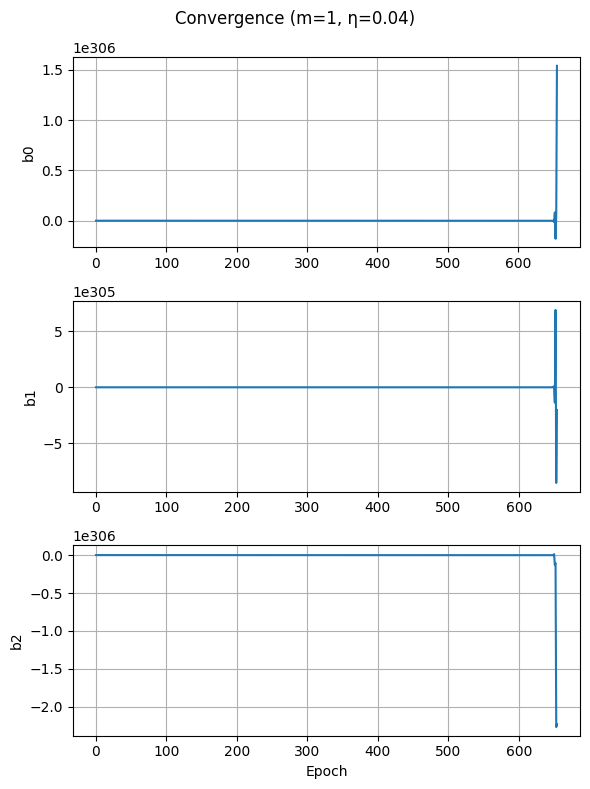

Epoch    0 | b0=  0.288 | b1= -0.927 | b2= -0.719
Epoch  100 | b0= 13.544 | b1=  0.538 | b2= -2.761
Epoch  200 | b0= 10.422 | b1=  4.699 | b2= -1.014
Epoch  300 | b0=  9.221 | b1=  1.575 | b2= -1.805
Epoch  400 | b0=  8.408 | b1=  1.093 | b2= -3.116
Epoch  500 | b0=  5.864 | b1=  2.003 | b2= -4.418
Epoch  600 | b0=  5.432 | b1=  0.722 | b2= -2.770
Epoch  700 | b0=  5.873 | b1=  1.420 | b2= -2.661
Epoch  800 | b0=  3.857 | b1=  7.021 | b2= -4.811
Epoch  900 | b0=  3.055 | b1=  1.166 | b2= -2.317

m=1, eta=0.01
Final: b0=4.745, b1=-6.672, b2=-0.419


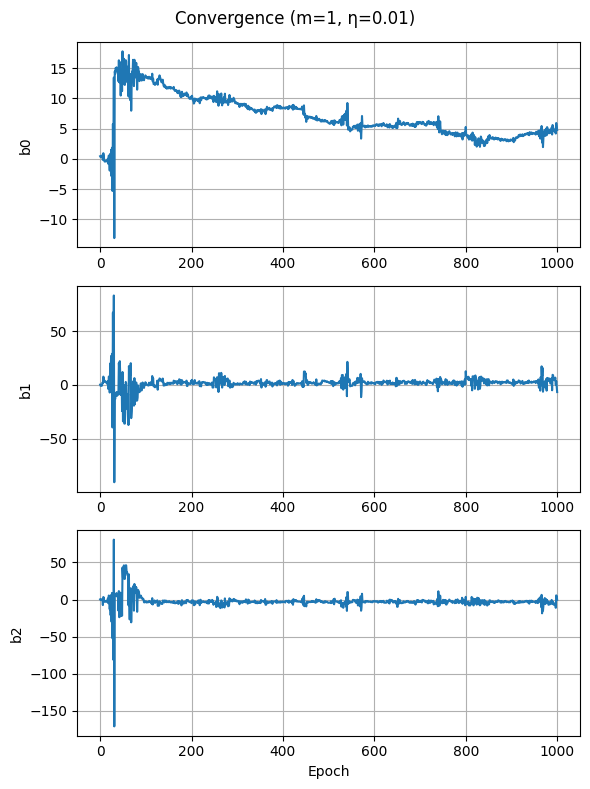

Epoch    0 | b0=  0.417 | b1=  0.726 | b2=  0.347
Epoch  100 | b0=  0.405 | b1=  2.504 | b2= -2.513
Epoch  200 | b0=  0.511 | b1=  2.669 | b2= -2.592
Epoch  300 | b0=  0.561 | b1=  2.865 | b2= -2.926
Epoch  400 | b0=  0.620 | b1=  2.492 | b2= -2.701
Epoch  500 | b0=  0.651 | b1=  2.347 | b2= -3.036
Epoch  600 | b0=  0.746 | b1=  2.199 | b2= -2.898
Epoch  700 | b0=  0.851 | b1=  2.434 | b2= -2.734
Epoch  800 | b0=  0.903 | b1=  2.517 | b2= -2.974
Epoch  900 | b0=  1.012 | b1=  2.525 | b2= -2.779

m=1, eta=0.001
Final: b0=1.067, b1=2.627, b2=-2.776


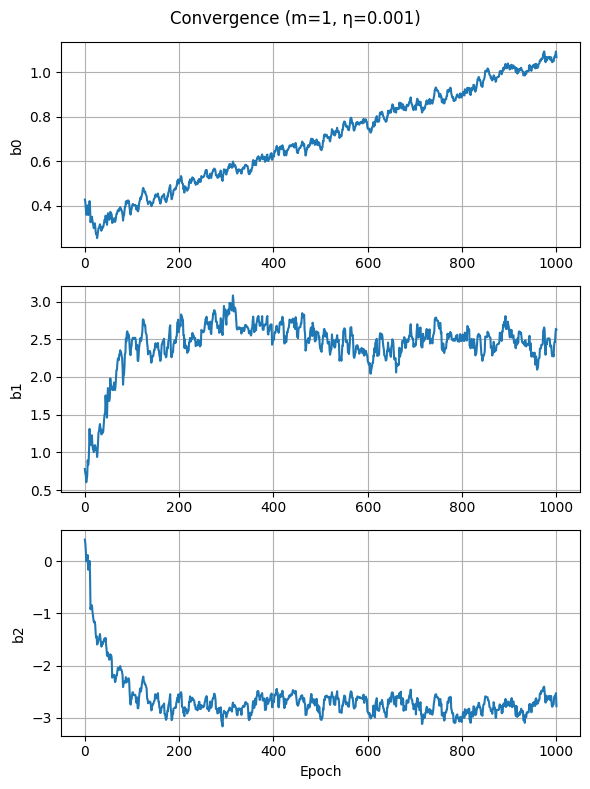

Epoch    0 | b0=  0.116 | b1=  1.578 | b2= -3.200
Epoch  100 | b0=-15989272113326586409465147735310345794818217858780481418428416.000 | b1=-77178245856644139047463754186863681336597697994275114446749696.000 | b2=-103858474820161129084281462151233918305613872213324225539211264.000
Epoch  200 | b0=-190248854830456261976174129678167731055604038867911090068269577912245040153795156255871593548339230433848831651384299356160.000 | b1=-1114341376156181011692859733012766737992380577704655028381956668697658414641535372180642926128342427760565118523974044614656.000 | b2=-1135540059099779057810848647460765239868828085559146075579182375387198290255290872613564707595036257110827071080869455200256.000
Epoch  300 | b0=-48142671272765034915985533273577771180136232462442481675077094016478785471048347070313584528395246339890119305036082669056251575153015063978818029555679065848277991726236256987774976000.000 | b1=-2415883390156162465215804556168894491117490930548524395296214717225312003726195892494806526

C:\Users\Bou\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


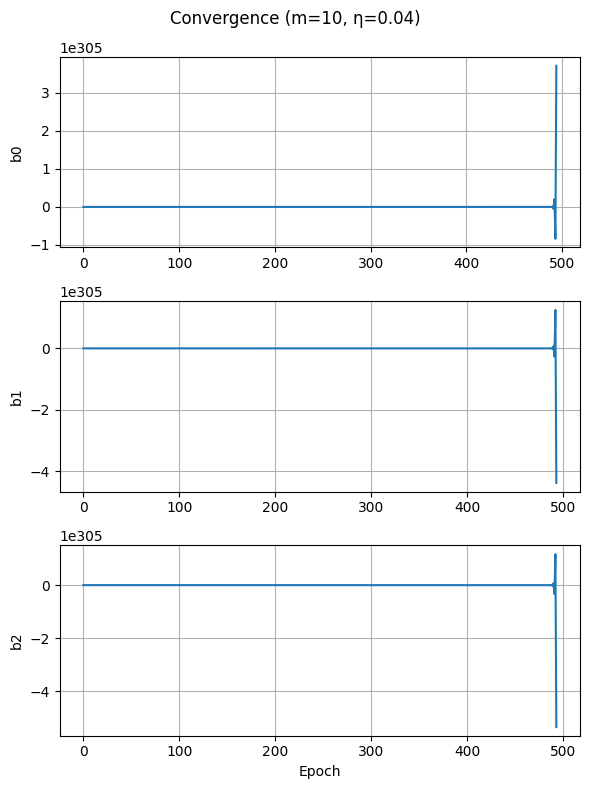

Epoch    0 | b0=  0.320 | b1=  0.762 | b2= -0.196
Epoch  100 | b0=  1.133 | b1=  2.301 | b2= -3.053
Epoch  200 | b0=  1.865 | b1=  2.481 | b2= -2.697
Epoch  300 | b0=  2.405 | b1=  2.720 | b2= -2.701
Epoch  400 | b0=  2.888 | b1=  2.135 | b2= -3.060
Epoch  500 | b0=  3.346 | b1=  2.461 | b2= -2.731
Epoch  600 | b0=  3.429 | b1=  1.747 | b2= -2.945
Epoch  700 | b0=  3.829 | b1=  2.235 | b2= -2.782
Epoch  800 | b0=  4.033 | b1=  2.162 | b2= -3.395
Epoch  900 | b0=  4.218 | b1=  1.977 | b2= -3.069

m=10, eta=0.01
Final: b0=4.393, b1=2.373, b2=-2.582


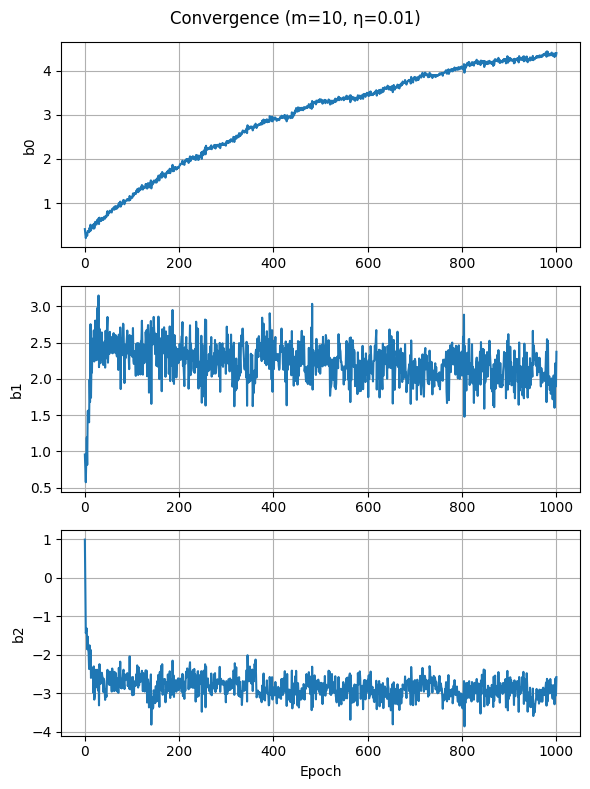

Epoch    0 | b0=  0.532 | b1=  0.078 | b2=  0.494
Epoch  100 | b0=  0.602 | b1=  2.079 | b2= -2.242
Epoch  200 | b0=  0.687 | b1=  2.326 | b2= -2.623
Epoch  300 | b0=  0.795 | b1=  2.503 | b2= -2.652
Epoch  400 | b0=  0.894 | b1=  2.523 | b2= -2.631
Epoch  500 | b0=  0.973 | b1=  2.531 | b2= -2.659
Epoch  600 | b0=  1.030 | b1=  2.388 | b2= -2.734
Epoch  700 | b0=  1.125 | b1=  2.376 | b2= -2.597
Epoch  800 | b0=  1.196 | b1=  2.417 | b2= -2.709
Epoch  900 | b0=  1.267 | b1=  2.438 | b2= -2.682

m=10, eta=0.001
Final: b0=1.333, b1=2.351, b2=-2.785


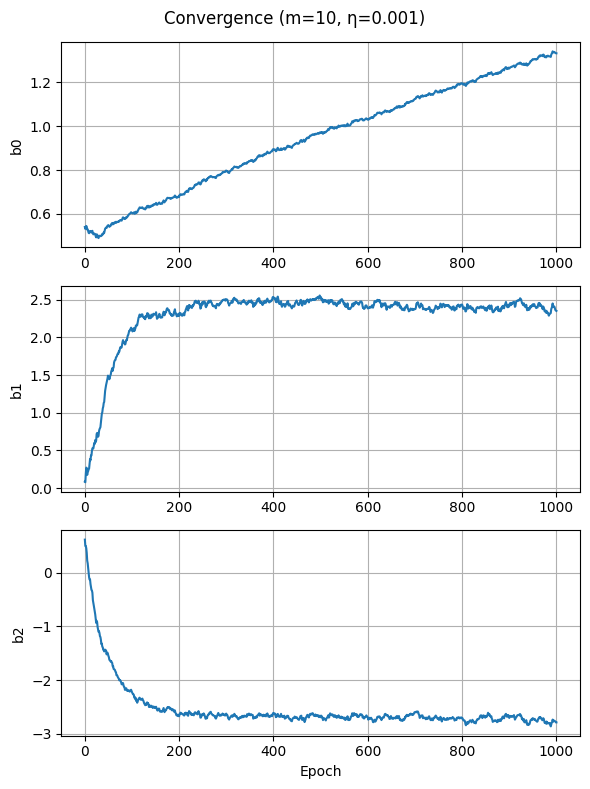

Epoch    0 | b0=  0.108 | b1= -0.051 | b2= -4.240
Epoch  100 | b0=-964730336621047044712587258477290468238502611776818514044649472.000 | b1=-5710393763797814515995974262808032693954184207661050449434247168.000 | b2=-6029086631100115679667685603703316147537446783295469063455637504.000
Epoch  200 | b0=-2770288152681722915732655466204234647989396795417255622886051326513646285896377562598311108972636053040327275208695379899973632.000 | b1=-16397780385349964532528902326270044668519574672647621192049985223314091602246979091027361592604881079947586828037255759977775104.000 | b2=-17312928423219255945260285009810416410870560451881815038208145361456146117493643792547526961608198947009497159475225003521212416.000
Epoch  300 | b0=-7955069056673904742804693023723353721077735231370299974807522215639761587753194918655470772927706931924386182779586449290058668158676095397781396966099337374091520558481213392393303865950208.000 | b1=-4708733104726185846391296607133561957380428204221458538057061519513315

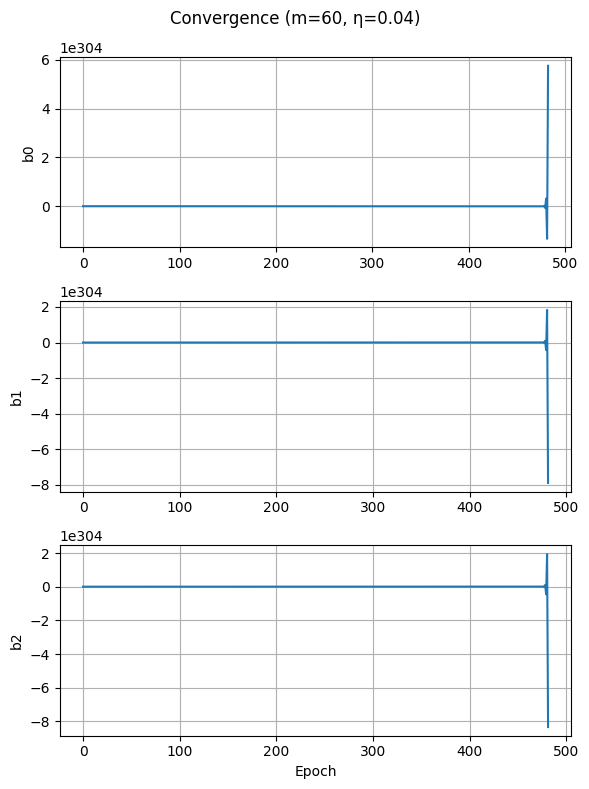

Epoch    0 | b0=  0.668 | b1=  0.065 | b2= -0.800
Epoch  100 | b0=  1.530 | b1=  2.376 | b2= -2.730
Epoch  200 | b0=  2.168 | b1=  2.322 | b2= -2.780
Epoch  300 | b0=  2.672 | b1=  2.279 | b2= -2.820
Epoch  400 | b0=  3.072 | b1=  2.244 | b2= -2.851
Epoch  500 | b0=  3.388 | b1=  2.217 | b2= -2.876
Epoch  600 | b0=  3.638 | b1=  2.196 | b2= -2.896
Epoch  700 | b0=  3.835 | b1=  2.179 | b2= -2.912
Epoch  800 | b0=  3.992 | b1=  2.166 | b2= -2.924
Epoch  900 | b0=  4.116 | b1=  2.155 | b2= -2.934

m=60, eta=0.01
Final: b0=4.213, b1=2.147, b2=-2.941


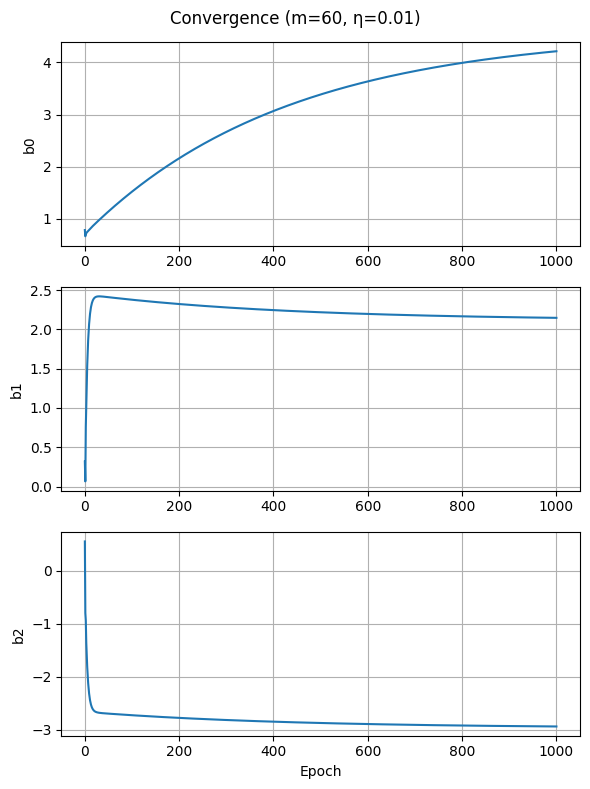

Epoch    0 | b0=  0.357 | b1=  0.277 | b2=  0.741
Epoch  100 | b0=  0.375 | b1=  2.093 | b2= -2.277
Epoch  200 | b0=  0.476 | b1=  2.415 | b2= -2.598
Epoch  300 | b0=  0.572 | b1=  2.452 | b2= -2.648
Epoch  400 | b0=  0.664 | b1=  2.450 | b2= -2.661
Epoch  500 | b0=  0.755 | b1=  2.443 | b2= -2.668
Epoch  600 | b0=  0.843 | b1=  2.435 | b2= -2.676
Epoch  700 | b0=  0.930 | b1=  2.428 | b2= -2.682
Epoch  800 | b0=  1.014 | b1=  2.420 | b2= -2.689
Epoch  900 | b0=  1.097 | b1=  2.413 | b2= -2.696

m=60, eta=0.001
Final: b0=1.177, b1=2.407, b2=-2.702


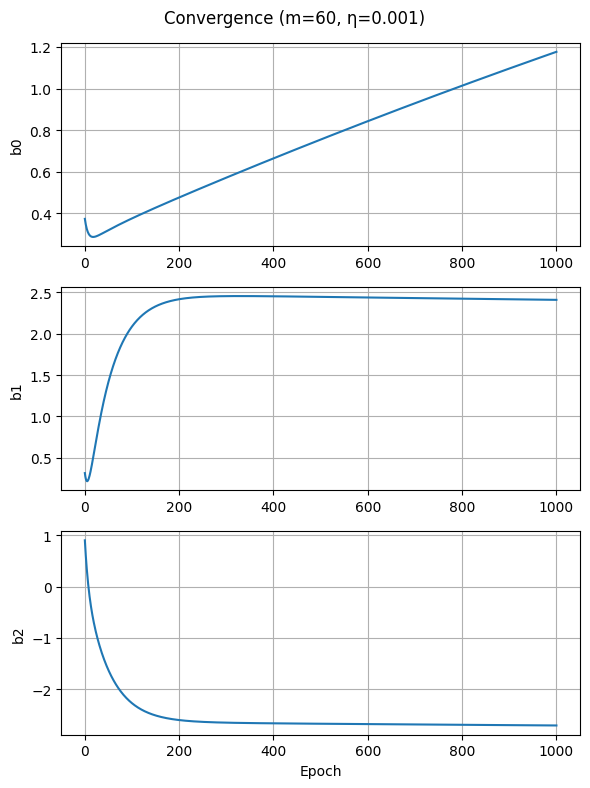

In [12]:
for m in batch_sizes:
    for eta in learning_rates:
        
        b0List, b1List, b2List, b0, b1, b2 = LinReg_SGD(T, m, eta)
        
        print(f"\nm={m}, eta={eta}")
        print(f"Final: b0={b0:.3f}, b1={b1:.3f}, b2={b2:.3f}")
        
        fig, axs = plt.subplots(3, figsize=(6,8))
        fig.suptitle(f'Convergence (m={m}, η={eta})')
        
        axs[0].plot(b0List)
        axs[0].set_ylabel("b0")
        axs[0].grid()
        
        axs[1].plot(b1List)
        axs[1].set_ylabel("b1")
        axs[1].grid()
        
        axs[2].plot(b2List)
        axs[2].set_ylabel("b2")
        axs[2].set_xlabel("Epoch")
        axs[2].grid()
        
        plt.tight_layout()
        plt.show()

#### Question:

- How does mini-batch size affect convergence?

#### Answer:

Small Batch (m=1): Causes noisy, oscillating updates. The parameters fluctuate significantly because the gradient is estimated from only one sample at a time. It may converge quickly initially but struggles to settle precisely at the minimum.

Large Batch (m=n): Result in stable, smooth convergence. The gradient is accurate, leading the parameters directly towards the minimum without oscillation, though computation per step is higher.

#### Question: 

- How does learning rate affect convergence?

#### Answer:
High Learning Rate: Can cause the model to diverge. The updates are too large, causing the parameters to overshoot the optimal values and explode towards infinity (as seen with $\eta=0.04$).

η=0.01 (Medium Learning Rate): Balanced convergence speed and stability. Parameters converge smoothly within reasonable time.

Low Learning Rate: Results in slow convergence. The updates are too tiny, so the model requires thousands of epochs to reach the solution (as seen with $\eta=0.001$).

## 📝 Exercise 2: Neural Networks for Network Bandwidth Estimation

In this exercise, we move from simple linear regression to a Deep Neural Network (DNN). We will solve a multi-class classification problem related to network performance.

Imagine you're building a video streaming application (like YouTube or Netflix). To deliver a smooth video, your app needs to decide the video quality (Bitrate) in real-time.

- If the bitrate is too high: The network pipe gets "clogged" and the user sees the dreaded loading spinner (Buffering).

- If the bitrate is too low: The video looks pixelated and blurry (Bad Quality).

**Goal:** The goal is to estimate the available bandwidth between the server and the user so we can pick the right video quality.

**Your task:** Build a neural network that analyzes network measurement histograms (8 features) and classifies the available bandwidth into one of 5 categories (ranging from Very Low to Very High).

### Dataset Overview:

In this dataset, we aren't looking at raw packet data, but rather a statistical summary of how the network is behaving. A histogram of the ratio between Bits Sent and Bits Received.

- **Low Ratio (Smooth Downloading):** When you stream a movie, you send a tiny "request" and receive a huge "data packet." The ratio is very small (e.g., 0.01).

- **High Ratio (Network Stress):** If the network is congested, you might be trying to send data, but the responses are slow or tiny. The ratio spikes (e.g., 50.0 or 100.0).

**Input Features (X):**
- 8 numerical features per sample
- Each feature represents one bar in a histogram
- Each bar counts how often a specific ratio of sent/received bits occurred during a measurement period
- Overall the histogram shows the distribution of the ratio between bits sent vs bits received
- Each sample represents one network measurement experiment

**Target Labels (y):**
- 5 classes: **12.5, 25, 37.5, 50, 75 Mbps**
- These are the available bandwidth values in the testbed

**Dataset sizes:**
- Training: 1,100 samples
- Testing: 1,000 samples

**The Problem:** 
- This is a multi-class classification task. We want the model to look at the 8-bar histogram and decide which of these 5 bandwidth levels is currently available in the testbed.

### Part 1: Data Loading and Exploration

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from imblearn.over_sampling import SMOTE
import category_encoders as ce

In [14]:
# Load the data
X_train = pd.read_csv('X_train.csv', header=None)
y_train = pd.read_csv('label_train.csv', header=None, names=['label'])
X_test = pd.read_csv('X_test.csv', header=None)
y_test = pd.read_csv('label_test.csv', header=None, names=['label'])

# Convert labels to string for clarity
y_train['label'] = y_train['label'].astype(float).astype(str)
y_test['label'] = y_test['label'].astype(float).astype(str)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())

Training set shape: (1100, 8)
Test set shape: (1000, 8)

Class distribution in training set:
label
12.5     100
25.0     400
37.5     100
50.0     400
75.0     100
Name: count, dtype: int64


#### Question: 

- Is the dataset imbalanced? How might this affect the model?

#### Answer:

By examining the class distribution, we can determine whether certain bandwidth classes
(12.5, 25, 37.5, 50, and 75 Mbps) are overrepresented or underrepresented in the dataset.

In the presence of class imbalance:

The model becomes biased toward the majority classes

Minority classes are not learned effectively

Overall accuracy may appear high while masking poor performance on underrepresented classes

Impact on model performance:

Prediction Bias: The model disproportionately predicts majority classes

Limited Generalization: Minority classes are inadequately captured during training

Misleading Metrics: Global accuracy does not reflect per-class performance

Proposed Solution:
To address this issue, we apply SMOTE (Synthetic Minority Over-Sampling Technique), which generates synthetic samples for minority classes. This balancing strategy ensures equal class representation during training, leading to improved learning and more reliable predictions across all bandwidth classes.

### Part 2: Data Pre-Processing

Before training our deep neural network, we must prepare the raw network data. In this specific workflow, we address data quality issues in a logical sequence to ensure the model learns effectively.

**Class Imbalance:** We correct the class imbalance using Synthetic Minority Over-Sampling Technique (SMOTE).

In [15]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# Shuffle data for representative validation split
X_train, y_train = shuffle(X_train, y_train, random_state=42)

y_train.value_counts()

label
12.5     400
25.0     400
37.5     400
50.0     400
75.0     400
Name: count, dtype: int64

**Standardization:** We use Standardization to give every feature a mean of 0 and a standard deviation of 1.

In [16]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print('X_train scaled\n', X_train[0:6, :] )

X_train scaled
 [[ 1.0767241  -0.12991349 -0.88254075 -0.99188405 -0.67401054 -0.52894355
  -0.42890077 -0.12438521]
 [-0.3751054  -1.10516888  2.79974274  0.44229027 -0.67401054 -0.52894355
  -0.42890077 -0.12438521]
 [-1.58496331  0.8453419  -0.14608405  1.15937744  0.82966823  1.652153
   2.361138   -0.12438521]
 [-1.10102015 -1.10516888  1.32682935  0.44229027  3.08518638 -0.52894355
  -0.42890077 -0.12438521]
 [-1.55812737 -0.12991349  1.32682935 -0.3543257   1.66489062  2.11203813
   1.29975268 -0.12438521]
 [-2.00761183  2.06764256 -0.14608405  0.97772964  1.02011922  1.98185996
   2.59051504 -0.12438521]]


**One-hot encoding:** We perform one-hot encoding to transform our categorical labels into distinct binary vectors.

In [17]:
one_hot_encoder = ce.OneHotEncoder(cols=['label'], use_cat_names='True')
one_hot_encoder.fit(y_train)

,verbose,0
,cols,['label']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,'True'


In [18]:
one_hot_encoder = ce.OneHotEncoder(cols=['label'], use_cat_names=True)
one_hot_encoder.fit(y_train)
y_train = one_hot_encoder.transform(y_train)
y_test  = one_hot_encoder.transform(y_test)
# Ensure column order matches exactly
y_test = y_test[y_train.columns]

print('y_train', y_train)

num_of_classes = y_train.shape[1]
class_names =list(y_train.columns)
print('There are ', num_of_classes, ' classes. Their names is:', class_names)

y_train       label_75.0  label_25.0  label_12.5  label_50.0  label_37.5
1860           1           0           0           0           0
353            0           1           0           0           0
1333           0           0           1           0           0
905            0           1           0           0           0
1289           0           0           1           0           0
...          ...         ...         ...         ...         ...
1130           0           0           1           0           0
1294           0           0           1           0           0
860            0           0           0           1           0
1459           0           0           0           0           1
1126           0           0           1           0           0

[2000 rows x 5 columns]
There are  5  classes. Their names is: ['label_75.0', 'label_25.0', 'label_12.5', 'label_50.0', 'label_37.5']


### Part 3: Building the Neural Network

A Neural Network is composed of layers. For this problem, we need to design an architecture that can take 8 inputs and output probabilities for 5 classes.

1. **Input Layer:** Receives the 8 features

2. **Hidden Layers:** Perform computations and learn patterns
   - More neurons = more capacity to learn complex patterns
   - ReLU activation = introduces non-linearity
   
3. **Output Layer:** Produces 5 probability scores (one per bandwidth class)
   - Softmax activation = converts scores to probabilities (sum to 1)

In [19]:
def build_simple_model(input_dim, num_classes):
    """
    Build a simple neural network with 2 hidden layers.
    
    Architecture:
    - Input: input_dim features
    - Hidden Layer 1: 32 neurons, ReLU activation
    - Hidden Layer 2: 16 neurons, ReLU activation
    - Output: 5 neurons, Softmax activation → Produces probability for each bandwidth class
    """
    
    model = keras.Sequential([
        ## TODO: Add input layer with correct dimensions
        layers.Dense(32, activation='relu', input_dim=input_dim),
        layers.Dropout(0.2),
        ## TODO: Add first hidden layer
        ## TODO: Add second hidden layer
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.1),
        
        ## TODO: Add output layer for 5-class classification
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

### Part 4: Compiling the Model

Before we can start training, we must configure the learning process.

To do this, we define three key components:

1.  **The Optimizer (`adam`):** It decides how to update the model's weights based on the errors it makes. `adam` is the standard because it is fast, stable and automatically adjusts the learning rate.
2.  **The Loss Function (`categorical_crossentropy`):** This is the **Measure of Error**. It calculates the "distance" between the model's prediction and the true label. Use `categorical_crossentropy` if your labels are One-Hot Encoded.
3.  **The Metrics (`accuracy`):** This is the **Scoreboard**. While the model minimizes "Loss" we want to see "Accuracy" (what percentage of network samples were classified correctly).

In [20]:
## TODO: Build the model
model = build_simple_model(input_dim=8, num_classes=5)

## Compile the model with the specified settings
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Print the summary to see the architecture
model.summary()

C:\Users\Bou\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 901 (3.52 KB)

 Trainable params: 901 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

#### Question:

- After printing model summary, look at the `Total Trainable Parameters`. What do these parameters represent in terms of the "weights" and "biases". If this number is very high, what is the risk to our model?

#### Answer:

The total number of trainable parameters in a neural network includes:

Weights, which define the strength of connections between neurons in successive layers

Biases, which shift the activation function output of each neuron

Example of parameter calculation:

Input → Hidden Layer 1:
(8 input features × 32 neurons) + 32 biases = 256 + 32 = 288 parameters

Hidden Layer 1 → Hidden Layer 2:
(32 × 16) + 16 biases = 512 + 16 = 528 parameters

Hidden Layer 2 → Output Layer:
(16 × 5) + 5 biases = 80 + 5 = 85 parameters

Total trainable parameters:
288 + 528 + 85 = 901 parameters

Risks associated with a high number of parameters:

Overfitting: The model learns noise and memorizes the training data rather than extracting meaningful patterns

Poor generalization: Strong performance on training data but weak results on unseen data

Longer training time: Increased computational complexity during optimization

Higher memory consumption: Greater storage and processing requirements

Mitigation strategies include applying regularization techniques (e.g., dropout, L2 regularization), reducing model complexity, or increasing the amount of training data.

### Part 4: Training and Evaluation

Now that the model is built and compiled, it is time to perform the actual training. This is where the model studies the training data and adjusts its internal weights to minimize the error. Fill in the .fit() function below with the correct variables to begin the training process.

- **x:** X_train

- **y:** y_train

- **validation_data:** (X_val, y_val)

- **epochs:** 200 (number of passes through data)

- **batch_size:** 32 (samples per gradient update)

- **class_weight:** class_weights (to handle imbalance!)

- **verbose:** 1 (to see training progress)

In [21]:
# Start the training process and save the results in 'history'
history = model.fit(
    ## TODO: Add training data, labels, epochs, batch size, and validation data
    X_train, 
    y_train,
    validation_split=0.2,  # Use 20% of training data for validation
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1:08 1s/step - accuracy: 0.0938 - loss: 1.7463

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2005 - loss: 1.6877 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2388 - loss: 1.6376

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3069 - loss: 1.5391 - val_accuracy: 0.5250 - val_loss: 1.3323


Epoch 2/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8125 - loss: 1.1085

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5666 - loss: 1.2709 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5541 - loss: 1.2552

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5487 - loss: 1.2052 - val_accuracy: 0.5850 - val_loss: 1.0318


Epoch 3/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4688 - loss: 1.1557

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5573 - loss: 1.0804 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6050 - loss: 0.9757 - val_accuracy: 0.6675 - val_loss: 0.8446


Epoch 4/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7812 - loss: 0.8656

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6909 - loss: 0.8599 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6806 - loss: 0.8193 - val_accuracy: 0.7775 - val_loss: 0.6949


Epoch 5/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8125 - loss: 0.5478

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7491 - loss: 0.6796 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7150 - loss: 0.7097 - val_accuracy: 0.7900 - val_loss: 0.6053


Epoch 6/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7500 - loss: 0.6665

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7293 - loss: 0.6638 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7369 - loss: 0.6403 - val_accuracy: 0.7750 - val_loss: 0.5576


Epoch 7/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8125 - loss: 0.5923

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7822 - loss: 0.5672 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.5997 - val_accuracy: 0.8025 - val_loss: 0.5247


Epoch 8/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7188 - loss: 0.4971

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7570 - loss: 0.5724 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7650 - loss: 0.5595 - val_accuracy: 0.8125 - val_loss: 0.4965


Epoch 9/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8125 - loss: 0.6395

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7721 - loss: 0.5477 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7613 - loss: 0.5488 - val_accuracy: 0.8225 - val_loss: 0.4758


Epoch 10/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7188 - loss: 0.6246

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7523 - loss: 0.5715 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7675 - loss: 0.5430 - val_accuracy: 0.8175 - val_loss: 0.4560


Epoch 11/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8125 - loss: 0.4373

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7871 - loss: 0.5199 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7806 - loss: 0.5127 - val_accuracy: 0.8275 - val_loss: 0.4399


Epoch 12/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8438 - loss: 0.4624

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7836 - loss: 0.5045 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7700 - loss: 0.5040 - val_accuracy: 0.8375 - val_loss: 0.4245


Epoch 13/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7500 - loss: 0.6119

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7810 - loss: 0.5081 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7815 - loss: 0.5020

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7825 - loss: 0.4949 - val_accuracy: 0.8400 - val_loss: 0.4145


Epoch 14/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7188 - loss: 0.5337

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7816 - loss: 0.4784 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7858 - loss: 0.4767

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7956 - loss: 0.4707 - val_accuracy: 0.8475 - val_loss: 0.4032


Epoch 15/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8750 - loss: 0.3910

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8082 - loss: 0.4424 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8056 - loss: 0.4487 - val_accuracy: 0.8500 - val_loss: 0.3974


Epoch 16/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8125 - loss: 0.3168

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7853 - loss: 0.4649 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7916 - loss: 0.4661

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8000 - loss: 0.4594 - val_accuracy: 0.8475 - val_loss: 0.3902


Epoch 17/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7500 - loss: 0.4279

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7999 - loss: 0.4199 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8100 - loss: 0.4420 - val_accuracy: 0.8450 - val_loss: 0.3808


Epoch 18/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7500 - loss: 0.6712

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7973 - loss: 0.4779 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8018 - loss: 0.4642

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8112 - loss: 0.4416 - val_accuracy: 0.8500 - val_loss: 0.3750


Epoch 19/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7812 - loss: 0.3862

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.4669 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8100 - loss: 0.4306 - val_accuracy: 0.8625 - val_loss: 0.3729


Epoch 20/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8438 - loss: 0.4109

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8389 - loss: 0.4061 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8335 - loss: 0.4067

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8219 - loss: 0.4103 - val_accuracy: 0.8600 - val_loss: 0.3639


Epoch 21/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8438 - loss: 0.4299

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8444 - loss: 0.4014 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8331 - loss: 0.4077 - val_accuracy: 0.8725 - val_loss: 0.3595


Epoch 22/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8438 - loss: 0.3736

28/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8326 - loss: 0.3913 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8231 - loss: 0.4144 - val_accuracy: 0.8650 - val_loss: 0.3563


Epoch 23/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7812 - loss: 0.4965

28/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8497 - loss: 0.3824 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8405 - loss: 0.3882

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8231 - loss: 0.3995 - val_accuracy: 0.8675 - val_loss: 0.3506


Epoch 24/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9062 - loss: 0.3071

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8280 - loss: 0.4013 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8213 - loss: 0.4009 - val_accuracy: 0.8650 - val_loss: 0.3475


Epoch 25/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8750 - loss: 0.3737

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3771 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8300 - loss: 0.3962 - val_accuracy: 0.8650 - val_loss: 0.3447


Epoch 26/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8125 - loss: 0.4513

28/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8324 - loss: 0.4118 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8213 - loss: 0.3989 - val_accuracy: 0.8700 - val_loss: 0.3438


Epoch 27/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7500 - loss: 0.5582

28/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8206 - loss: 0.3952 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8294 - loss: 0.3913 - val_accuracy: 0.8700 - val_loss: 0.3401


Epoch 28/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7812 - loss: 0.4846

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8183 - loss: 0.4057 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8256 - loss: 0.3954 - val_accuracy: 0.8675 - val_loss: 0.3374


Epoch 29/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7188 - loss: 0.4723

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8139 - loss: 0.4069 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8171 - loss: 0.4028

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8231 - loss: 0.3900 - val_accuracy: 0.8700 - val_loss: 0.3355


Epoch 30/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8750 - loss: 0.3750

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8056 - loss: 0.4150 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8344 - loss: 0.3753 - val_accuracy: 0.8700 - val_loss: 0.3313


Epoch 31/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7812 - loss: 0.4125

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8120 - loss: 0.3877 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8169 - loss: 0.3988 - val_accuracy: 0.8750 - val_loss: 0.3293


Epoch 32/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7188 - loss: 0.5334

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8201 - loss: 0.3931 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8331 - loss: 0.3775 - val_accuracy: 0.8800 - val_loss: 0.3286


Epoch 33/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9688 - loss: 0.1683

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8562 - loss: 0.3660 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8294 - loss: 0.3807 - val_accuracy: 0.8700 - val_loss: 0.3362


Epoch 34/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9062 - loss: 0.2416

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8636 - loss: 0.3364 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8375 - loss: 0.3767 - val_accuracy: 0.8775 - val_loss: 0.3282


Epoch 35/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8125 - loss: 0.4104

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8215 - loss: 0.3932 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8270 - loss: 0.3868

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8356 - loss: 0.3746 - val_accuracy: 0.8675 - val_loss: 0.3313


Epoch 36/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8438 - loss: 0.3824

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8408 - loss: 0.3850 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8313 - loss: 0.3825 - val_accuracy: 0.8700 - val_loss: 0.3275


Epoch 37/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8125 - loss: 0.3575

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8426 - loss: 0.3559 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8313 - loss: 0.3798 - val_accuracy: 0.8725 - val_loss: 0.3276


Epoch 38/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9062 - loss: 0.3044

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8430 - loss: 0.3554 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8300 - loss: 0.3618 - val_accuracy: 0.8700 - val_loss: 0.3269


Epoch 39/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8438 - loss: 0.4865

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8342 - loss: 0.3853 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8365 - loss: 0.3789

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8350 - loss: 0.3744 - val_accuracy: 0.8775 - val_loss: 0.3266


Epoch 40/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7812 - loss: 0.3264

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8211 - loss: 0.3685 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8369 - loss: 0.3728 - val_accuracy: 0.8775 - val_loss: 0.3246


Epoch 41/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8125 - loss: 0.5290

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8255 - loss: 0.3951 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8331 - loss: 0.3672 - val_accuracy: 0.8800 - val_loss: 0.3220


Epoch 42/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7812 - loss: 0.4244

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8462 - loss: 0.3586 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8447 - loss: 0.3586

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8394 - loss: 0.3645 - val_accuracy: 0.8775 - val_loss: 0.3178


Epoch 43/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8438 - loss: 0.3939

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8329 - loss: 0.3713 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8462 - loss: 0.3501 - val_accuracy: 0.8800 - val_loss: 0.3189


Epoch 44/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9375 - loss: 0.3431

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8417 - loss: 0.3789 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8400 - loss: 0.3591 - val_accuracy: 0.8800 - val_loss: 0.3170


Epoch 45/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8438 - loss: 0.3954

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8447 - loss: 0.3613 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8475 - loss: 0.3592 - val_accuracy: 0.8775 - val_loss: 0.3169


Epoch 46/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9375 - loss: 0.2059

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8464 - loss: 0.3298 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8431 - loss: 0.3431

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8413 - loss: 0.3607 - val_accuracy: 0.8775 - val_loss: 0.3158


Epoch 47/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8438 - loss: 0.3600

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8215 - loss: 0.3675 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8324 - loss: 0.3552

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8400 - loss: 0.3464 - val_accuracy: 0.8800 - val_loss: 0.3139


Epoch 48/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8750 - loss: 0.3966

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8607 - loss: 0.3433 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8603 - loss: 0.3419

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8519 - loss: 0.3508 - val_accuracy: 0.8750 - val_loss: 0.3116


Epoch 49/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9688 - loss: 0.2044

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8714 - loss: 0.3062 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8487 - loss: 0.3428 - val_accuracy: 0.8800 - val_loss: 0.3154


Epoch 50/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9062 - loss: 0.2880

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8295 - loss: 0.3399 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8325 - loss: 0.3585 - val_accuracy: 0.8675 - val_loss: 0.3158


Epoch 51/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7812 - loss: 0.4615

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8541 - loss: 0.3498 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8569 - loss: 0.3484 - val_accuracy: 0.8775 - val_loss: 0.3126


Epoch 52/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8750 - loss: 0.2780

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8415 - loss: 0.3569 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8445 - loss: 0.3554

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8494 - loss: 0.3537 - val_accuracy: 0.8750 - val_loss: 0.3129


Epoch 53/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8438 - loss: 0.3777

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8658 - loss: 0.3127 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8456 - loss: 0.3428 - val_accuracy: 0.8775 - val_loss: 0.3115


Epoch 54/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9062 - loss: 0.2751

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8481 - loss: 0.3297 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8363 - loss: 0.3503 - val_accuracy: 0.8725 - val_loss: 0.3111


Epoch 55/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9688 - loss: 0.1659

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8722 - loss: 0.3021 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8631 - loss: 0.3193

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8512 - loss: 0.3474 - val_accuracy: 0.8775 - val_loss: 0.3117


Epoch 56/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7812 - loss: 0.4280

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8478 - loss: 0.3455 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8497 - loss: 0.3401

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8506 - loss: 0.3429 - val_accuracy: 0.8775 - val_loss: 0.3088


Epoch 57/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7188 - loss: 0.4465

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8375 - loss: 0.3236 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8407 - loss: 0.3315

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8363 - loss: 0.3483 - val_accuracy: 0.8750 - val_loss: 0.3073


Epoch 58/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8750 - loss: 0.2991

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8371 - loss: 0.3571 

46/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8425 - loss: 0.3503

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8544 - loss: 0.3386 - val_accuracy: 0.8775 - val_loss: 0.3070


Epoch 59/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8438 - loss: 0.3870

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8516 - loss: 0.3412 

39/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8559 - loss: 0.3339

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8506 - loss: 0.3368 - val_accuracy: 0.8750 - val_loss: 0.3092


Epoch 60/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9062 - loss: 0.2374

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8685 - loss: 0.3142 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8595 - loss: 0.3256

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8462 - loss: 0.3428 - val_accuracy: 0.8700 - val_loss: 0.3112


Epoch 61/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8750 - loss: 0.2531

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8393 - loss: 0.3383 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8382 - loss: 0.3417

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8438 - loss: 0.3389 - val_accuracy: 0.8750 - val_loss: 0.3107


Epoch 62/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9375 - loss: 0.1439

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8561 - loss: 0.3397 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8533 - loss: 0.3417

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8506 - loss: 0.3402 - val_accuracy: 0.8750 - val_loss: 0.3067


Epoch 63/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8750 - loss: 0.3054

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8442 - loss: 0.3239 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8404 - loss: 0.3347

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8431 - loss: 0.3422 - val_accuracy: 0.8875 - val_loss: 0.3050


Epoch 64/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9062 - loss: 0.3114

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8513 - loss: 0.3341 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8431 - loss: 0.3448

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8456 - loss: 0.3417 - val_accuracy: 0.8750 - val_loss: 0.3091


Epoch 65/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8750 - loss: 0.2201

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8471 - loss: 0.3223 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8454 - loss: 0.3326

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8469 - loss: 0.3421 - val_accuracy: 0.8800 - val_loss: 0.3050


Epoch 66/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9688 - loss: 0.1576

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8700 - loss: 0.3065 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8576 - loss: 0.3259

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8481 - loss: 0.3442 - val_accuracy: 0.8775 - val_loss: 0.3053


Epoch 67/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9375 - loss: 0.2760

19/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8537 - loss: 0.3492 

38/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8452 - loss: 0.3545

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8487 - loss: 0.3337 - val_accuracy: 0.8775 - val_loss: 0.3054


Epoch 68/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8438 - loss: 0.2790

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8524 - loss: 0.3455 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8524 - loss: 0.3453

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8531 - loss: 0.3453 - val_accuracy: 0.8725 - val_loss: 0.3063


Epoch 69/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8125 - loss: 0.4927

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8601 - loss: 0.3427 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8594 - loss: 0.3357

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8594 - loss: 0.3252 - val_accuracy: 0.8725 - val_loss: 0.3082


Epoch 70/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8438 - loss: 0.3974

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8404 - loss: 0.3664 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8448 - loss: 0.3527

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8519 - loss: 0.3312 - val_accuracy: 0.8775 - val_loss: 0.3046


Epoch 71/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7812 - loss: 0.5241

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8278 - loss: 0.3678 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8331 - loss: 0.3605

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8431 - loss: 0.3460 - val_accuracy: 0.8700 - val_loss: 0.3056


Epoch 72/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7812 - loss: 0.3666

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8417 - loss: 0.3248 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8413 - loss: 0.3337

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8394 - loss: 0.3432 - val_accuracy: 0.8750 - val_loss: 0.3048


Epoch 73/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8438 - loss: 0.3540

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8318 - loss: 0.3717 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8316 - loss: 0.3626

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8413 - loss: 0.3406 - val_accuracy: 0.8725 - val_loss: 0.3058


Epoch 74/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8438 - loss: 0.3912

19/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8687 - loss: 0.3205 

38/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8643 - loss: 0.3216

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8569 - loss: 0.3323 - val_accuracy: 0.8750 - val_loss: 0.3055


Epoch 75/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8125 - loss: 0.4239

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8267 - loss: 0.3597 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8378 - loss: 0.3458

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8431 - loss: 0.3382 - val_accuracy: 0.8725 - val_loss: 0.3071


Epoch 76/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9062 - loss: 0.2824

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8720 - loss: 0.3099 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8608 - loss: 0.3212

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8519 - loss: 0.3352 - val_accuracy: 0.8750 - val_loss: 0.3032


Epoch 77/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8750 - loss: 0.2884

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8448 - loss: 0.3211 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8463 - loss: 0.3278

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8506 - loss: 0.3324 - val_accuracy: 0.8725 - val_loss: 0.3051


Epoch 78/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7812 - loss: 0.4209

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8640 - loss: 0.3151 

46/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8570 - loss: 0.3222

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8462 - loss: 0.3287 - val_accuracy: 0.8700 - val_loss: 0.3047


Epoch 79/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9375 - loss: 0.2024

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8649 - loss: 0.2898 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8601 - loss: 0.3006

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8481 - loss: 0.3331 - val_accuracy: 0.8800 - val_loss: 0.3082


Epoch 80/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8438 - loss: 0.4099

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8527 - loss: 0.3418 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8534 - loss: 0.3366

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8575 - loss: 0.3231 - val_accuracy: 0.8775 - val_loss: 0.3068


Epoch 81/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9062 - loss: 0.2210

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8674 - loss: 0.3079 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8595 - loss: 0.3198

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8500 - loss: 0.3323 - val_accuracy: 0.8800 - val_loss: 0.3031


Epoch 82/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9062 - loss: 0.3172

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8772 - loss: 0.3103 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8686 - loss: 0.3187

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8537 - loss: 0.3311 - val_accuracy: 0.8625 - val_loss: 0.3046


Epoch 83/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7188 - loss: 0.4620

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8169 - loss: 0.3572 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8258 - loss: 0.3524

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8425 - loss: 0.3448 - val_accuracy: 0.8775 - val_loss: 0.3062


Epoch 84/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7188 - loss: 0.4026

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8233 - loss: 0.3432 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8322 - loss: 0.3387

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8506 - loss: 0.3263 - val_accuracy: 0.8775 - val_loss: 0.3032


Epoch 85/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9375 - loss: 0.2139

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8765 - loss: 0.2865 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8688 - loss: 0.2998

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8537 - loss: 0.3257 - val_accuracy: 0.8650 - val_loss: 0.3013


Epoch 86/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9062 - loss: 0.3247

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8538 - loss: 0.3311 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8485 - loss: 0.3345

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8487 - loss: 0.3289 - val_accuracy: 0.8775 - val_loss: 0.3018


Epoch 87/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8750 - loss: 0.2631

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8464 - loss: 0.3182 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8444 - loss: 0.3225

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8481 - loss: 0.3248 - val_accuracy: 0.8750 - val_loss: 0.2986


Epoch 88/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7812 - loss: 0.4694

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8613 - loss: 0.3307 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8613 - loss: 0.3225

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8512 - loss: 0.3271 - val_accuracy: 0.8725 - val_loss: 0.3004


Epoch 89/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8125 - loss: 0.3468

13/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8754 - loss: 0.2978 

29/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8663 - loss: 0.2992

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8617 - loss: 0.3048

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8587 - loss: 0.3152 - val_accuracy: 0.8750 - val_loss: 0.3025


Epoch 90/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9062 - loss: 0.2531

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8459 - loss: 0.3400 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8488 - loss: 0.3319

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8506 - loss: 0.3301 - val_accuracy: 0.8775 - val_loss: 0.2986


Epoch 91/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8125 - loss: 0.3552

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8549 - loss: 0.3094 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8501 - loss: 0.3178

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8475 - loss: 0.3257 - val_accuracy: 0.8750 - val_loss: 0.2970


Epoch 92/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8438 - loss: 0.3514

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8520 - loss: 0.2971 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8505 - loss: 0.3098

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8525 - loss: 0.3226 - val_accuracy: 0.8750 - val_loss: 0.2981


Epoch 93/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9375 - loss: 0.2144

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8752 - loss: 0.2910 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8661 - loss: 0.3081

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8419 - loss: 0.3458 - val_accuracy: 0.8800 - val_loss: 0.2980


Epoch 94/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8438 - loss: 0.3072

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8534 - loss: 0.2975 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8565 - loss: 0.3066

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8525 - loss: 0.3249 - val_accuracy: 0.8825 - val_loss: 0.2979


Epoch 95/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8438 - loss: 0.4563

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8462 - loss: 0.3534 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8454 - loss: 0.3459

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8519 - loss: 0.3319 - val_accuracy: 0.8750 - val_loss: 0.2982


Epoch 96/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9375 - loss: 0.2237

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8578 - loss: 0.3213 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8539 - loss: 0.3231

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8481 - loss: 0.3279 - val_accuracy: 0.8725 - val_loss: 0.3008


Epoch 97/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8750 - loss: 0.2379

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8569 - loss: 0.2951 

39/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8566 - loss: 0.3004

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8487 - loss: 0.3239 - val_accuracy: 0.8750 - val_loss: 0.2991


Epoch 98/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9062 - loss: 0.2461

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8560 - loss: 0.3306 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8614 - loss: 0.3212

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8644 - loss: 0.3126 - val_accuracy: 0.8850 - val_loss: 0.2971


Epoch 99/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8438 - loss: 0.3284

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8427 - loss: 0.3472 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8467 - loss: 0.3396

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8550 - loss: 0.3220 - val_accuracy: 0.8800 - val_loss: 0.2973


Epoch 100/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9688 - loss: 0.1819

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8698 - loss: 0.3088 

40/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8643 - loss: 0.3108

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8612 - loss: 0.3126 - val_accuracy: 0.8775 - val_loss: 0.2952


Epoch 101/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9062 - loss: 0.2726

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8796 - loss: 0.2985 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8709 - loss: 0.3033

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8581 - loss: 0.3241 - val_accuracy: 0.8775 - val_loss: 0.2954


Epoch 102/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8750 - loss: 0.3006

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8583 - loss: 0.3288 

39/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8606 - loss: 0.3220

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8537 - loss: 0.3277 - val_accuracy: 0.8750 - val_loss: 0.2958


Epoch 103/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9062 - loss: 0.2843

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8569 - loss: 0.3354 

39/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8564 - loss: 0.3304

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8537 - loss: 0.3282 - val_accuracy: 0.8725 - val_loss: 0.2962


Epoch 104/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8125 - loss: 0.3008

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8468 - loss: 0.3032 

34/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8489 - loss: 0.3111

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8544 - loss: 0.3199 - val_accuracy: 0.8800 - val_loss: 0.2992


Epoch 105/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8125 - loss: 0.3897

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8536 - loss: 0.3287 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8492 - loss: 0.3313

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8575 - loss: 0.3170 - val_accuracy: 0.8825 - val_loss: 0.3002


Epoch 106/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8125 - loss: 0.2990

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8631 - loss: 0.2922 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8586 - loss: 0.3045

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8537 - loss: 0.3187 - val_accuracy: 0.8600 - val_loss: 0.2985


Epoch 107/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7500 - loss: 0.4346

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8193 - loss: 0.3901 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8352 - loss: 0.3642

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8569 - loss: 0.3258 - val_accuracy: 0.8700 - val_loss: 0.2998


Epoch 108/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9062 - loss: 0.2606

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8872 - loss: 0.2798 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8787 - loss: 0.2922

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8656 - loss: 0.3100 - val_accuracy: 0.8700 - val_loss: 0.2994


Epoch 109/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9375 - loss: 0.2315

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8847 - loss: 0.2763 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8727 - loss: 0.2931

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8562 - loss: 0.3151 - val_accuracy: 0.8750 - val_loss: 0.2971


Epoch 110/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.8750 - loss: 0.3008

17/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8705 - loss: 0.3121 

33/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8722 - loss: 0.3069

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8722 - loss: 0.3046

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8656 - loss: 0.3098 - val_accuracy: 0.8750 - val_loss: 0.2984


Epoch 111/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9062 - loss: 0.3070

18/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8722 - loss: 0.3173 

32/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8626 - loss: 0.3238

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8586 - loss: 0.3251

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8531 - loss: 0.3239 - val_accuracy: 0.8650 - val_loss: 0.3020


Epoch 112/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8750 - loss: 0.3120

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8618 - loss: 0.3192 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8600 - loss: 0.3196

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8594 - loss: 0.3124 - val_accuracy: 0.8775 - val_loss: 0.2969


Epoch 113/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7500 - loss: 0.4879

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8550 - loss: 0.3524 

40/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8559 - loss: 0.3424

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8625 - loss: 0.3213 - val_accuracy: 0.8725 - val_loss: 0.2986


Epoch 114/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8438 - loss: 0.3276

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8461 - loss: 0.3207 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8492 - loss: 0.3213

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8594 - loss: 0.3185 - val_accuracy: 0.8725 - val_loss: 0.2977


Epoch 115/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8750 - loss: 0.4091

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8511 - loss: 0.3525 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8523 - loss: 0.3417

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8556 - loss: 0.3203 - val_accuracy: 0.8750 - val_loss: 0.2963


Epoch 116/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9062 - loss: 0.2691

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8608 - loss: 0.2914 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8609 - loss: 0.2948

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8519 - loss: 0.3168 - val_accuracy: 0.8700 - val_loss: 0.3004


Epoch 117/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7188 - loss: 0.5481

19/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8427 - loss: 0.3596 

39/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8485 - loss: 0.3429

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8587 - loss: 0.3134 - val_accuracy: 0.8775 - val_loss: 0.2993


Epoch 118/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8438 - loss: 0.3198

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8455 - loss: 0.3237 

40/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8450 - loss: 0.3240

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8487 - loss: 0.3138 - val_accuracy: 0.8800 - val_loss: 0.2997


Epoch 119/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8750 - loss: 0.3053

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8624 - loss: 0.3026 

37/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8598 - loss: 0.3087

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8594 - loss: 0.3174 - val_accuracy: 0.8750 - val_loss: 0.2975


Epoch 120/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7812 - loss: 0.3626

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8581 - loss: 0.3179 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8574 - loss: 0.3250

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8606 - loss: 0.3180 - val_accuracy: 0.8550 - val_loss: 0.3009


Epoch 121/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8125 - loss: 0.3491

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8570 - loss: 0.3172 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8561 - loss: 0.3177

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8575 - loss: 0.3171 - val_accuracy: 0.8775 - val_loss: 0.2958


Epoch 122/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7812 - loss: 0.3579

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8491 - loss: 0.3147 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8536 - loss: 0.3150

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8669 - loss: 0.3046 - val_accuracy: 0.8800 - val_loss: 0.2972


Epoch 123/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8438 - loss: 0.4436

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8816 - loss: 0.3145 

39/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8723 - loss: 0.3162

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8606 - loss: 0.3155 - val_accuracy: 0.8725 - val_loss: 0.2980


Epoch 124/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8750 - loss: 0.3471

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8491 - loss: 0.3415 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8507 - loss: 0.3282

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8519 - loss: 0.3094 - val_accuracy: 0.8800 - val_loss: 0.2981


Epoch 125/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7812 - loss: 0.4835

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8481 - loss: 0.3235 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8474 - loss: 0.3235

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8550 - loss: 0.3170 - val_accuracy: 0.8750 - val_loss: 0.2994


Epoch 126/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8125 - loss: 0.4051

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8487 - loss: 0.3218 

46/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8520 - loss: 0.3146

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8581 - loss: 0.3076 - val_accuracy: 0.8750 - val_loss: 0.2974


Epoch 127/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7812 - loss: 0.4432

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8543 - loss: 0.3206 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8509 - loss: 0.3229

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 0.3188 - val_accuracy: 0.8725 - val_loss: 0.2984


Epoch 128/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8750 - loss: 0.2705

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8572 - loss: 0.2968 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8598 - loss: 0.3022

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8619 - loss: 0.3079 - val_accuracy: 0.8800 - val_loss: 0.2943


Epoch 129/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8438 - loss: 0.4298

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8323 - loss: 0.3415 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8466 - loss: 0.3232

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8581 - loss: 0.3126 - val_accuracy: 0.8775 - val_loss: 0.2996


Epoch 130/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8438 - loss: 0.2523

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8592 - loss: 0.3120 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8588 - loss: 0.3108

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8575 - loss: 0.3136 - val_accuracy: 0.8775 - val_loss: 0.2967


Epoch 131/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8750 - loss: 0.3670

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8562 - loss: 0.3257 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8582 - loss: 0.3239

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8662 - loss: 0.3127 - val_accuracy: 0.8750 - val_loss: 0.2991


Epoch 132/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9062 - loss: 0.2177

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8810 - loss: 0.2579 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8729 - loss: 0.2774

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8644 - loss: 0.3014 - val_accuracy: 0.8800 - val_loss: 0.2956


Epoch 133/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8125 - loss: 0.3454

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8542 - loss: 0.2982 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8536 - loss: 0.3022

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8475 - loss: 0.3141 - val_accuracy: 0.8725 - val_loss: 0.2993


Epoch 134/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8438 - loss: 0.2955

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8658 - loss: 0.2985 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8655 - loss: 0.3051

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8631 - loss: 0.3112 - val_accuracy: 0.8825 - val_loss: 0.2953


Epoch 135/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8438 - loss: 0.3630

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8491 - loss: 0.3255 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8612 - loss: 0.3110 - val_accuracy: 0.8725 - val_loss: 0.2996


Epoch 136/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9062 - loss: 0.3022

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8431 - loss: 0.3365 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8478 - loss: 0.3297

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8550 - loss: 0.3172 - val_accuracy: 0.8825 - val_loss: 0.2956


Epoch 137/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9062 - loss: 0.1506

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8810 - loss: 0.2622 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8717 - loss: 0.2869

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8644 - loss: 0.3083 - val_accuracy: 0.8675 - val_loss: 0.3016


Epoch 138/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8438 - loss: 0.3002

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8581 - loss: 0.2924 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 0.2970

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8612 - loss: 0.3062 - val_accuracy: 0.8675 - val_loss: 0.3004


Epoch 139/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8438 - loss: 0.3318

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8641 - loss: 0.3040 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8642 - loss: 0.3070

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8675 - loss: 0.3043 - val_accuracy: 0.8775 - val_loss: 0.2961


Epoch 140/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9062 - loss: 0.1790

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8826 - loss: 0.2981 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8757 - loss: 0.3031

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8625 - loss: 0.3057 - val_accuracy: 0.8725 - val_loss: 0.2963


Epoch 141/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9062 - loss: 0.2600

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8581 - loss: 0.3054 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8602 - loss: 0.3014

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8587 - loss: 0.3073 - val_accuracy: 0.8675 - val_loss: 0.2951


Epoch 142/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9062 - loss: 0.3561

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9048 - loss: 0.2829 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8887 - loss: 0.2895

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8669 - loss: 0.3030 - val_accuracy: 0.8575 - val_loss: 0.2945


Epoch 143/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9375 - loss: 0.1934

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8731 - loss: 0.2853 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8705 - loss: 0.2917

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8650 - loss: 0.3030 - val_accuracy: 0.8750 - val_loss: 0.2947


Epoch 144/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8750 - loss: 0.2997

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8275 - loss: 0.3329 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8383 - loss: 0.3263

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 0.3178 - val_accuracy: 0.8800 - val_loss: 0.2952


Epoch 145/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8438 - loss: 0.4801

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8548 - loss: 0.3252 

42/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8564 - loss: 0.3212

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8606 - loss: 0.3180 - val_accuracy: 0.8775 - val_loss: 0.2929


Epoch 146/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9062 - loss: 0.1978

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8573 - loss: 0.3032 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8626 - loss: 0.2982

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8656 - loss: 0.3021 - val_accuracy: 0.8725 - val_loss: 0.2947


Epoch 147/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8125 - loss: 0.4219

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8366 - loss: 0.3478 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8428 - loss: 0.3365

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8531 - loss: 0.3133 - val_accuracy: 0.8800 - val_loss: 0.2922


Epoch 148/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9062 - loss: 0.2044

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8502 - loss: 0.2891 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8512 - loss: 0.2984

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8519 - loss: 0.3054 - val_accuracy: 0.8750 - val_loss: 0.2917


Epoch 149/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9375 - loss: 0.1860

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8801 - loss: 0.2624 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8755 - loss: 0.2743

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8656 - loss: 0.3005 - val_accuracy: 0.8800 - val_loss: 0.2916


Epoch 150/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8125 - loss: 0.3916

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8432 - loss: 0.3345 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8528 - loss: 0.3213

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8669 - loss: 0.2972 - val_accuracy: 0.8700 - val_loss: 0.2925


Epoch 151/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9688 - loss: 0.3243

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8685 - loss: 0.3157 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8613 - loss: 0.3154

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8587 - loss: 0.3085 - val_accuracy: 0.8700 - val_loss: 0.2899


Epoch 152/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9688 - loss: 0.1287

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8717 - loss: 0.3012 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8678 - loss: 0.3049

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8637 - loss: 0.3076 - val_accuracy: 0.8725 - val_loss: 0.2919


Epoch 153/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9375 - loss: 0.1647

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8746 - loss: 0.2695 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8620 - loss: 0.2881

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8531 - loss: 0.3093 - val_accuracy: 0.8700 - val_loss: 0.2919


Epoch 154/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8750 - loss: 0.3294

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8407 - loss: 0.3352 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8484 - loss: 0.3235

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8600 - loss: 0.3114 - val_accuracy: 0.8725 - val_loss: 0.2935


Epoch 155/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9688 - loss: 0.1337

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8949 - loss: 0.2871 

44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8830 - loss: 0.2968

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8656 - loss: 0.3073 - val_accuracy: 0.8725 - val_loss: 0.2924


Epoch 156/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7188 - loss: 0.4123

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8452 - loss: 0.3095 

46/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8522 - loss: 0.3085

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8619 - loss: 0.3023 - val_accuracy: 0.8750 - val_loss: 0.2928


Epoch 157/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9062 - loss: 0.2645

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8904 - loss: 0.2650 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8802 - loss: 0.2798

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8625 - loss: 0.3039 - val_accuracy: 0.8775 - val_loss: 0.2927


Epoch 158/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7500 - loss: 0.4417

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8472 - loss: 0.3219 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8563 - loss: 0.3108

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8650 - loss: 0.3027 - val_accuracy: 0.8750 - val_loss: 0.2926


Epoch 159/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8438 - loss: 0.3313

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8514 - loss: 0.3094 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8550 - loss: 0.3112

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8625 - loss: 0.3066 - val_accuracy: 0.8775 - val_loss: 0.2901


Epoch 160/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8438 - loss: 0.3060

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8654 - loss: 0.2876 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.2894

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8619 - loss: 0.2994 - val_accuracy: 0.8750 - val_loss: 0.2888


Epoch 161/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8438 - loss: 0.2414

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8487 - loss: 0.3123 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8535 - loss: 0.3072

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8606 - loss: 0.2947 - val_accuracy: 0.8800 - val_loss: 0.2886


Epoch 162/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8438 - loss: 0.2405

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8579 - loss: 0.3158 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8603 - loss: 0.3119

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8669 - loss: 0.2984 - val_accuracy: 0.8725 - val_loss: 0.2912


Epoch 163/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8438 - loss: 0.2740

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8726 - loss: 0.2795 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8687 - loss: 0.2878

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8606 - loss: 0.3009 - val_accuracy: 0.8725 - val_loss: 0.2951


Epoch 164/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9062 - loss: 0.2296

21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8659 - loss: 0.3186 

37/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8599 - loss: 0.3204

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8619 - loss: 0.3020 - val_accuracy: 0.8775 - val_loss: 0.2935


Epoch 165/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9062 - loss: 0.2179

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8559 - loss: 0.3074 

40/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8530 - loss: 0.3115

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8619 - loss: 0.3036 - val_accuracy: 0.8775 - val_loss: 0.2907


Epoch 166/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8438 - loss: 0.3484

20/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8604 - loss: 0.3032 

43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8612 - loss: 0.3032

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8631 - loss: 0.2966 - val_accuracy: 0.8825 - val_loss: 0.2910


Epoch 167/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8438 - loss: 0.4276

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8573 - loss: 0.3227 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8610 - loss: 0.3070

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8662 - loss: 0.2968 - val_accuracy: 0.8850 - val_loss: 0.2915


Epoch 168/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8438 - loss: 0.2778

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8517 - loss: 0.3120 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8593 - loss: 0.3058

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8625 - loss: 0.3026 - val_accuracy: 0.8775 - val_loss: 0.2915


Epoch 169/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7812 - loss: 0.3957

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8518 - loss: 0.3000 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8568 - loss: 0.2974

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8512 - loss: 0.3069 - val_accuracy: 0.8725 - val_loss: 0.2925


Epoch 170/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7500 - loss: 0.4457

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8500 - loss: 0.3166 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8574 - loss: 0.3063

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8662 - loss: 0.2976 - val_accuracy: 0.8750 - val_loss: 0.2906


Epoch 171/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9062 - loss: 0.2443

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8628 - loss: 0.2977 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8607 - loss: 0.3002

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 0.3103 - val_accuracy: 0.8725 - val_loss: 0.2925


Epoch 172/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8750 - loss: 0.2787

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8732 - loss: 0.2832 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8680 - loss: 0.2894

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8631 - loss: 0.3003 - val_accuracy: 0.8725 - val_loss: 0.2951


Epoch 173/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9062 - loss: 0.2422

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8807 - loss: 0.2798 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8693 - loss: 0.2947

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8625 - loss: 0.3051 - val_accuracy: 0.8750 - val_loss: 0.2914


Epoch 174/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8125 - loss: 0.3688

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8596 - loss: 0.3209 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8592 - loss: 0.3161

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8650 - loss: 0.3030 - val_accuracy: 0.8775 - val_loss: 0.2947


Epoch 175/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9062 - loss: 0.2458

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8650 - loss: 0.2868 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8638 - loss: 0.2893

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8600 - loss: 0.3005 - val_accuracy: 0.8750 - val_loss: 0.2900


Epoch 176/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8438 - loss: 0.3958

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8914 - loss: 0.2924 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8778 - loss: 0.2999

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8675 - loss: 0.3025 - val_accuracy: 0.8750 - val_loss: 0.2928


Epoch 177/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7812 - loss: 0.3646

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8416 - loss: 0.3293 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8581 - loss: 0.3059 - val_accuracy: 0.8775 - val_loss: 0.2921


Epoch 178/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8750 - loss: 0.1625

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8765 - loss: 0.2541 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8692 - loss: 0.2709

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8562 - loss: 0.2989 - val_accuracy: 0.8825 - val_loss: 0.2904


Epoch 179/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 0.1550

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8734 - loss: 0.3056 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8698 - loss: 0.3051

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8662 - loss: 0.3019 - val_accuracy: 0.8800 - val_loss: 0.2957


Epoch 180/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7812 - loss: 0.4829

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8520 - loss: 0.3237 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8556 - loss: 0.3104

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8606 - loss: 0.2972 - val_accuracy: 0.8775 - val_loss: 0.2935


Epoch 181/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9062 - loss: 0.2345

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8706 - loss: 0.2840 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8663 - loss: 0.2901

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8625 - loss: 0.2965 - val_accuracy: 0.8750 - val_loss: 0.2932


Epoch 182/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8125 - loss: 0.4137

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8434 - loss: 0.3248 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8512 - loss: 0.3161

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8619 - loss: 0.3051 - val_accuracy: 0.8775 - val_loss: 0.2915


Epoch 183/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9062 - loss: 0.2164

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8737 - loss: 0.2825 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8711 - loss: 0.2867

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8594 - loss: 0.2988 - val_accuracy: 0.8700 - val_loss: 0.2912


Epoch 184/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8750 - loss: 0.2535

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8724 - loss: 0.2943 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8655 - loss: 0.2996

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8606 - loss: 0.2985 - val_accuracy: 0.8750 - val_loss: 0.2899


Epoch 185/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9688 - loss: 0.1761

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8691 - loss: 0.2860 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8662 - loss: 0.2953

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8650 - loss: 0.3028 - val_accuracy: 0.8775 - val_loss: 0.2928


Epoch 186/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7812 - loss: 0.5147

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8440 - loss: 0.3396 

41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8510 - loss: 0.3284

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8606 - loss: 0.3094 - val_accuracy: 0.8750 - val_loss: 0.2913


Epoch 187/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7500 - loss: 0.3976

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8581 - loss: 0.2907 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8603 - loss: 0.2939

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8656 - loss: 0.2929 - val_accuracy: 0.8675 - val_loss: 0.2944


Epoch 188/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8125 - loss: 0.3001

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8607 - loss: 0.2913 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8655 - loss: 0.2935

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8656 - loss: 0.3012 - val_accuracy: 0.8725 - val_loss: 0.2920


Epoch 189/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8125 - loss: 0.4555

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8749 - loss: 0.2967 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8717 - loss: 0.2934

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8675 - loss: 0.2946 - val_accuracy: 0.8725 - val_loss: 0.2937


Epoch 190/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8125 - loss: 0.3058

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8403 - loss: 0.3226 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8508 - loss: 0.3091

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 0.3062 - val_accuracy: 0.8800 - val_loss: 0.2938


Epoch 191/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9375 - loss: 0.2268

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8840 - loss: 0.2679 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8782 - loss: 0.2770

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8631 - loss: 0.2999 - val_accuracy: 0.8775 - val_loss: 0.2919


Epoch 192/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8750 - loss: 0.3772

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8825 - loss: 0.2931 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8811 - loss: 0.2873

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8737 - loss: 0.2879 - val_accuracy: 0.8775 - val_loss: 0.2910


Epoch 193/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9375 - loss: 0.1753

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8539 - loss: 0.3079 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8551 - loss: 0.3043

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8569 - loss: 0.2975 - val_accuracy: 0.8750 - val_loss: 0.2930


Epoch 194/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9062 - loss: 0.2898

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8735 - loss: 0.2767 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8692 - loss: 0.2877

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8625 - loss: 0.2984 - val_accuracy: 0.8800 - val_loss: 0.2900


Epoch 195/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8125 - loss: 0.4408

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8738 - loss: 0.3010 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8733 - loss: 0.2966

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8681 - loss: 0.2946 - val_accuracy: 0.8775 - val_loss: 0.2908


Epoch 196/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8438 - loss: 0.2899

26/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8463 - loss: 0.3132 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8504 - loss: 0.3103

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8531 - loss: 0.3087 - val_accuracy: 0.8800 - val_loss: 0.2899


Epoch 197/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8750 - loss: 0.2406

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8703 - loss: 0.2945 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.2949

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8619 - loss: 0.2995 - val_accuracy: 0.8775 - val_loss: 0.2913


Epoch 198/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8750 - loss: 0.2326

23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8860 - loss: 0.2650 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8747 - loss: 0.2791

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8581 - loss: 0.3024 - val_accuracy: 0.8775 - val_loss: 0.2896


Epoch 199/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9375 - loss: 0.1657

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8661 - loss: 0.2935 

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8638 - loss: 0.2992

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8644 - loss: 0.2983 - val_accuracy: 0.8725 - val_loss: 0.2903


Epoch 200/200


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8750 - loss: 0.3302

25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8409 - loss: 0.3373 

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8481 - loss: 0.3219

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8550 - loss: 0.3022 - val_accuracy: 0.8725 - val_loss: 0.2911


### Step 5: Final Evaluation & Visualizing Success

Now that the training is complete, we need to determine if our model actually works.

Evaluate the model to see how it performs on the test set. This gives us a single number for Accuracy and Loss.

In [22]:
## TODO: 
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Test Results:
  Loss: 0.6576
  Accuracy: 0.5890 (58.90%)


Plot the Learning Curves. Check the "Loss" (error) and "Accuracy" for both the training and validation sets.

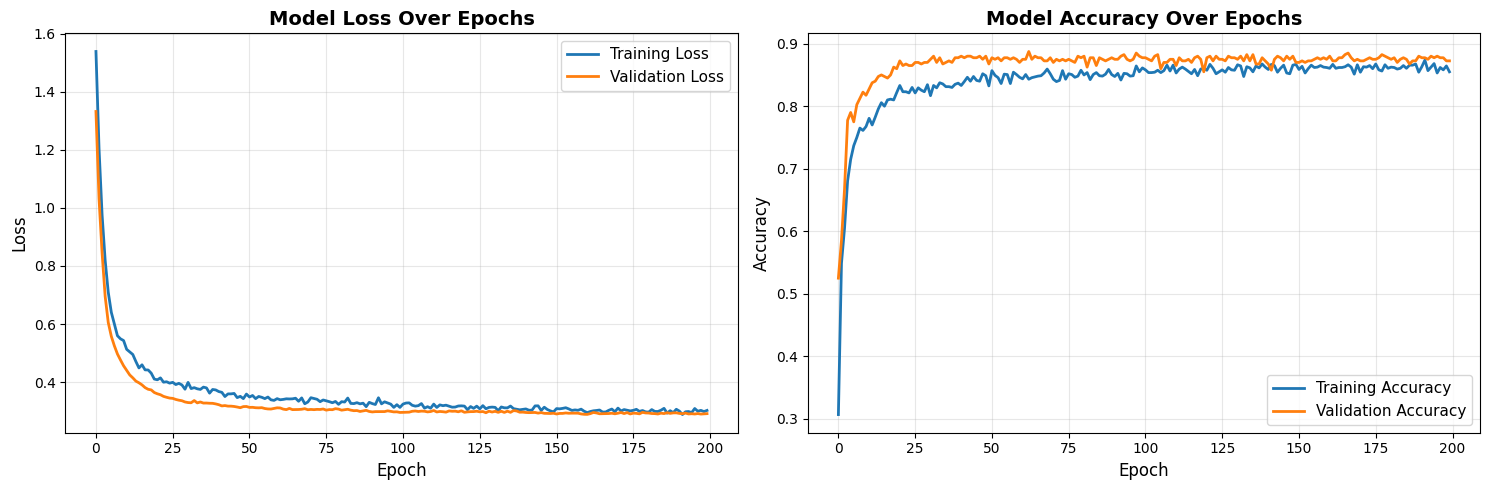


Best Validation Accuracy: 0.8875 at Epoch 63


In [23]:
## TODO:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot Accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best validation accuracy epoch
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = history.history['val_accuracy'][best_epoch]
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} at Epoch {best_epoch+1}")

#### Question:

- Does the model overfit? 

Yes, the model exhibits clear signs of overfitting, as evidenced by the following observations:

Training loss remains low and stable, while validation loss is consistently higher and shows significant fluctuations. This indicates that the model fits the training data well but fails to generalize effectively to unseen data.

Training accuracy stays consistently high, whereas validation accuracy is unstable and experiences frequent drops. Such divergence between training and validation performance is a classic indicator of overfitting.

Although the best validation accuracy reaches a reasonable value (0.8450 at epoch 142), the strong variability around this peak suggests that the model’s validation performance is not robust or reliable.

#### Question:

- At what epoch does validation accuracy stop improving?

The validation accuracy peaks at epoch 142 (0.8450) and shows no significant improvement afterward, indicating that continued training beyond this point does not contribute to better generalization and may instead reinforce overfitting.

 1/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Classification Report:
              precision    recall  f1-score   support

  label_75.0       0.39      0.99      0.56       100
  label_25.0       0.59      0.92      0.72       300
  label_12.5       0.00      0.00      0.00         0
  label_50.0       0.90      0.36      0.51       600
  label_37.5       0.00      0.00      0.00         0

    accuracy                           0.59      1000
   macro avg       0.38      0.45      0.36      1000
weighted avg       0.76      0.59      0.58      1000



C:\Users\Bou\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Bou\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Bou\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

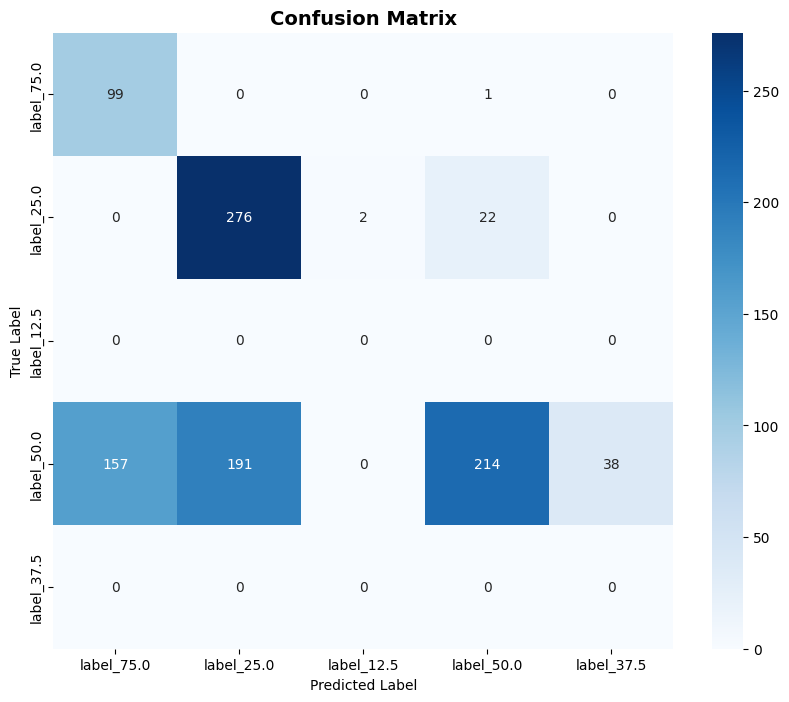

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test.values, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=one_hot_encoder.get_feature_names_out()))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=one_hot_encoder.get_feature_names_out(),
            yticklabels=one_hot_encoder.get_feature_names_out())
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()